<a href="https://colab.research.google.com/github/chithrakumardakshan-cloud/northstar-analytics/blob/main/notebooks/03_python_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# NORTHSTAR URBAN MOBILITY ANALYTICS
# PYTHON DATA PROCESSING
# ==========================================

# STEP 1 — IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# STEP 2 — LOAD DATASETS

orders = pd.read_csv('orders.csv')
deliveries = pd.read_csv('deliveries.csv')
customers = pd.read_csv('customers.csv')
drivers = pd.read_csv('drivers.csv')
vehicles = pd.read_csv('vehicles.csv')
hubs = pd.read_csv('hubs.csv')
incidents = pd.read_csv('incidents.csv')
complaints = pd.read_csv('complaints.csv')
app_events = pd.read_csv('app_events.csv')

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [3]:
# STEP 3 — CHECK DATASET SHAPES

tables = {
    'orders': orders,
    'deliveries': deliveries,
    'customers': customers,
    'drivers': drivers,
    'vehicles': vehicles,
    'hubs': hubs,
    'incidents': incidents,
    'complaints': complaints,
    'app_events': app_events
}

for name, df in tables.items():
    print(f"{name} --> Rows: {df.shape[0]}, Columns: {df.shape[1]}")

orders --> Rows: 1250, Columns: 11
deliveries --> Rows: 950, Columns: 13
customers --> Rows: 650, Columns: 9
drivers --> Rows: 170, Columns: 8
vehicles --> Rows: 120, Columns: 8
hubs --> Rows: 8, Columns: 5
incidents --> Rows: 280, Columns: 7
complaints --> Rows: 320, Columns: 10
app_events --> Rows: 640, Columns: 10


In [4]:
# STEP 4 — PREVIEW DATA

orders.head()
deliveries.head()
customers.head()
# STEP 5 — DATA INFORMATION

orders.info()
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1250 non-null   object 
 1   customer_id            1250 non-null   object 
 2   service_type           1250 non-null   object 
 3   order_created_at       1250 non-null   object 
 4   promised_window_hours  1250 non-null   int64  
 5   pickup_zone            1250 non-null   object 
 6   dropoff_zone           1250 non-null   object 
 7   priority_level         1250 non-null   object 
 8   order_value            1250 non-null   float64
 9   booking_channel        1225 non-null   object 
 10  special_handling_flag  1250 non-null   int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 107.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 13 columns):
 #   Column                         Non-Null Cou

In [5]:
# STEP 6 — DATA CLEANING

def format_zone(column):
    return column.str.strip().str.title()

orders['pickup_zone'] = format_zone(orders['pickup_zone'])
orders['dropoff_zone'] = format_zone(orders['dropoff_zone'])

customers['home_zone'] = format_zone(customers['home_zone'])

drivers['base_zone'] = format_zone(drivers['base_zone'])

vehicles['assigned_zone'] = format_zone(vehicles['assigned_zone'])

app_events['zone_context'] = format_zone(app_events['zone_context'])

print("Zone cleaning completed.")

Zone cleaning completed.


In [6]:
# STEP 7 — CONVERT DATE COLUMNS

orders['order_created_at'] = pd.to_datetime(
    orders['order_created_at'],
    errors='coerce'
)

deliveries['dispatch_time'] = pd.to_datetime(
    deliveries['dispatch_time'],
    errors='coerce'
)

deliveries['delivery_completed_at'] = pd.to_datetime(
    deliveries['delivery_completed_at'],
    errors='coerce'
)

complaints['created_at'] = pd.to_datetime(
    complaints['created_at'],
    errors='coerce'
)

print("Datetime conversion completed.")

Datetime conversion completed.


In [7]:
# STEP 8 — FEATURE ENGINEERING

# Delivery duration in hours
deliveries['delivery_hours'] = (
    deliveries['delivery_completed_at']
    - deliveries['dispatch_time']
).dt.total_seconds() / 3600

# Cost per kilometer
deliveries['cost_per_km'] = (
    deliveries['fuel_or_charge_cost']
    / deliveries['route_distance_km']
)

# Negative duration flag
deliveries['negative_delivery_time'] = (
    deliveries['delivery_hours'] < 0
)

# Complaint month
complaints['complaint_month'] = (
    complaints['created_at']
    .dt.to_period('M')
)

print("Feature engineering completed.")

Feature engineering completed.


In [8]:
# STEP 9 — MISSING VALUE ANALYSIS

missing_report = pd.DataFrame()

for name, df in tables.items():

    missing = df.isnull().sum()

    missing = missing[missing > 0]

    temp = pd.DataFrame({
        'Column': missing.index,
        'Missing Values': missing.values,
        'Dataset': name
    })

    missing_report = pd.concat([missing_report, temp])

missing_report


,Column,Missing Values,Dataset
0,booking_channel,25,orders
0,delivery_completed_at,19,deliveries
1,customer_rating_post_delivery,14,deliveries
2,delivery_hours,19,deliveries
0,loyalty_score,20,customers
1,preferred_channel,13,customers
0,training_score,7,drivers
0,battery_health_pct,4,vehicles
0,resolved_hours,17,incidents
0,compensation_amount,16,complaints


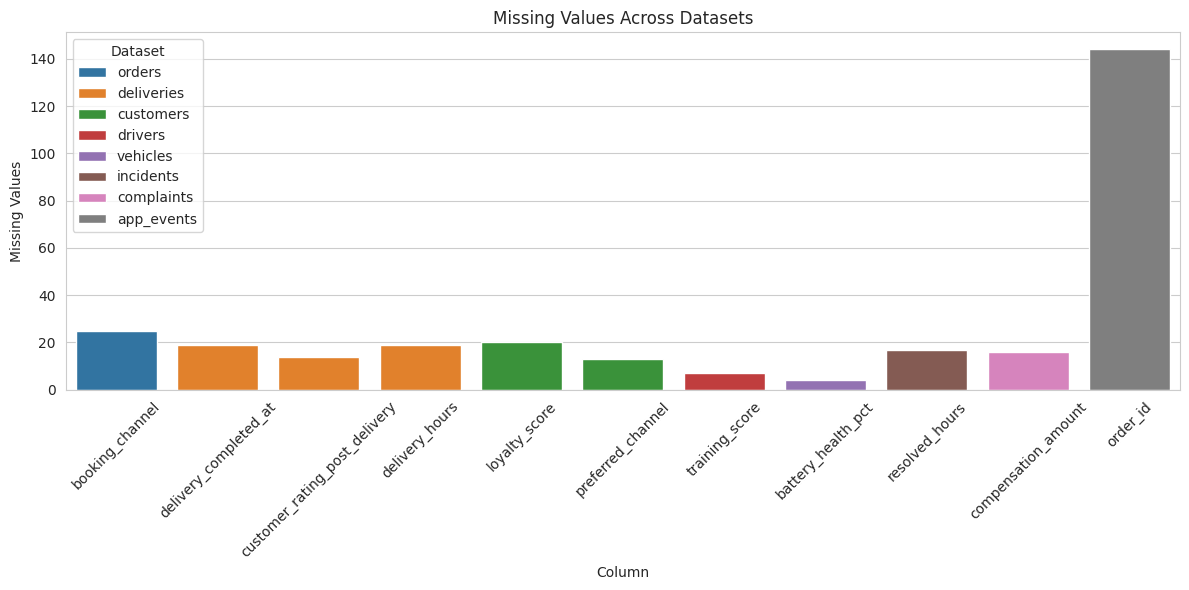

In [9]:
# STEP 10 — VISUALISE MISSING VALUES

plt.figure(figsize=(12,6))

sns.barplot(
    data=missing_report,
    x='Column',
    y='Missing Values',
    hue='Dataset'
)

plt.xticks(rotation=45)

plt.title('Missing Values Across Datasets')

plt.tight_layout()

plt.show()

In [10]:
# ANALYSIS 1 — DELIVERY FAILURE RATE

delivery_zone = deliveries.merge(
    hubs,
    on='hub_id',
    how='left'
)

zone_stats = delivery_zone.groupby('zone').agg(
    total_deliveries=('delivery_id', 'count'),
    failed_deliveries=('delivery_status',
                        lambda x: (x == 'Failed').sum()),
    late_deliveries=('delivery_status',
                      lambda x: (x == 'Late').sum()),
    average_rating=('customer_rating_post_delivery', 'mean')
).reset_index()

zone_stats['failure_rate'] = (
    zone_stats['failed_deliveries']
    / zone_stats['total_deliveries']
) * 100

zone_stats = zone_stats.sort_values(
    by='failure_rate',
    ascending=False
)

zone_stats

,zone,total_deliveries,failed_deliveries,late_deliveries,average_rating,failure_rate
1,Central,243,49,0,3.782479,20.164609
0,Airport,104,15,0,3.882136,14.423077
6,West,127,16,0,3.915476,12.598425
3,North,136,17,0,3.840593,12.500000
4,Riverside,115,14,0,3.881858,12.173913
5,South,106,10,0,3.950952,9.433962
2,East,119,11,0,3.895862,9.243697


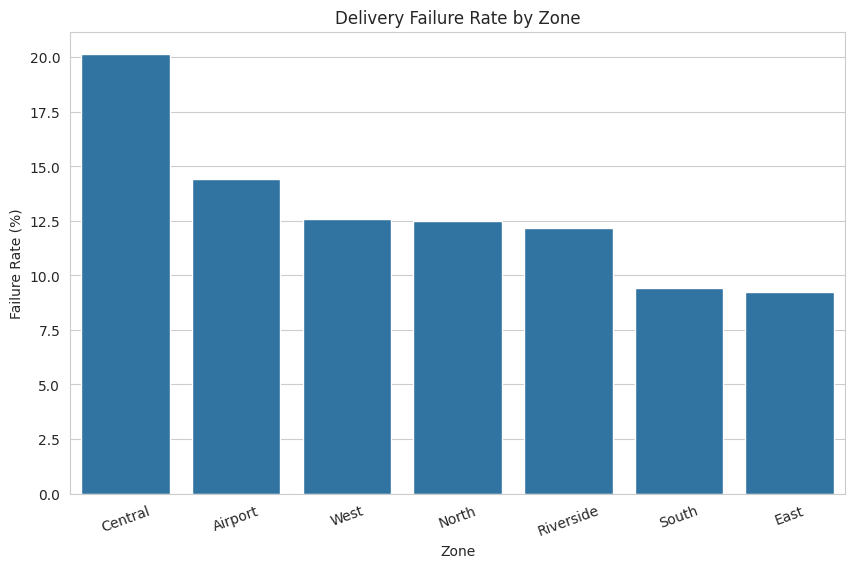

In [11]:
# CHART — FAILURE RATE BY ZONE

plt.figure(figsize=(10,6))

sns.barplot(
    data=zone_stats,
    x='zone',
    y='failure_rate'
)

plt.title('Delivery Failure Rate by Zone')

plt.xlabel('Zone')

plt.ylabel('Failure Rate (%)')

plt.xticks(rotation=20)

plt.show()

In [12]:
# ANALYSIS 2 — DRIVER PERFORMANCE

driver_analysis = deliveries.merge(
    drivers,
    on='driver_id',
    how='left'
)

driver_stats = driver_analysis.groupby('driver_id').agg(
    avg_override=('manual_route_override_count', 'mean'),
    avg_rating=('customer_rating_post_delivery', 'mean'),
    delivery_count=('delivery_id', 'count')
).reset_index()

driver_stats.head()

,driver_id,avg_override,avg_rating,delivery_count
0,D001,0.666667,4.096667,6
1,D002,1.000000,3.210000,7
2,D003,1.750000,4.445000,4
3,D004,0.777778,3.510000,9
4,D005,1.200000,3.530000,5


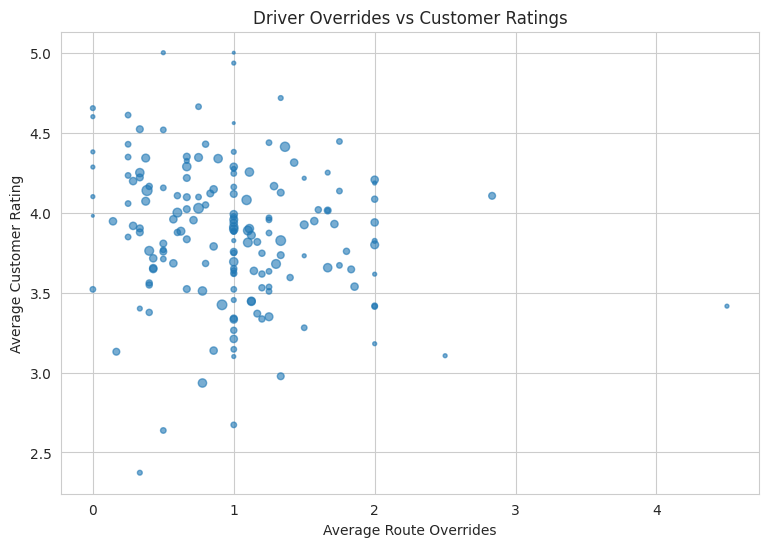

In [13]:
# CHART — DRIVER OVERRIDES VS RATINGS

plt.figure(figsize=(9,6))

plt.scatter(
    driver_stats['avg_override'],
    driver_stats['avg_rating'],
    s=driver_stats['delivery_count'] * 4,
    alpha=0.6
)

plt.title('Driver Overrides vs Customer Ratings')

plt.xlabel('Average Route Overrides')

plt.ylabel('Average Customer Rating')

plt.show()

In [14]:
# ANALYSIS 3 — COMPLAINT ANALYSIS

complaint_summary = complaints.groupby('complaint_type').agg(
    total_complaints=('complaint_id', 'count'),
    avg_compensation=('compensation_amount', 'mean'),
    avg_resolution_days=('resolution_days', 'mean')
).reset_index()

complaint_summary = complaint_summary.sort_values(
    by='total_complaints',
    ascending=False
)

complaint_summary

,complaint_type,total_complaints,avg_compensation,avg_resolution_days
3,Delay,101,18.051489,7.257426
5,MissedPickup,64,22.593651,7.640625
0,AppIssue,53,19.614400,8.603774
4,DriverBehaviour,51,21.153478,8.156863
6,SupportExperience,20,17.125000,7.450000
1,Billing,16,23.871250,7.750000
2,Damage,15,23.982000,11.333333


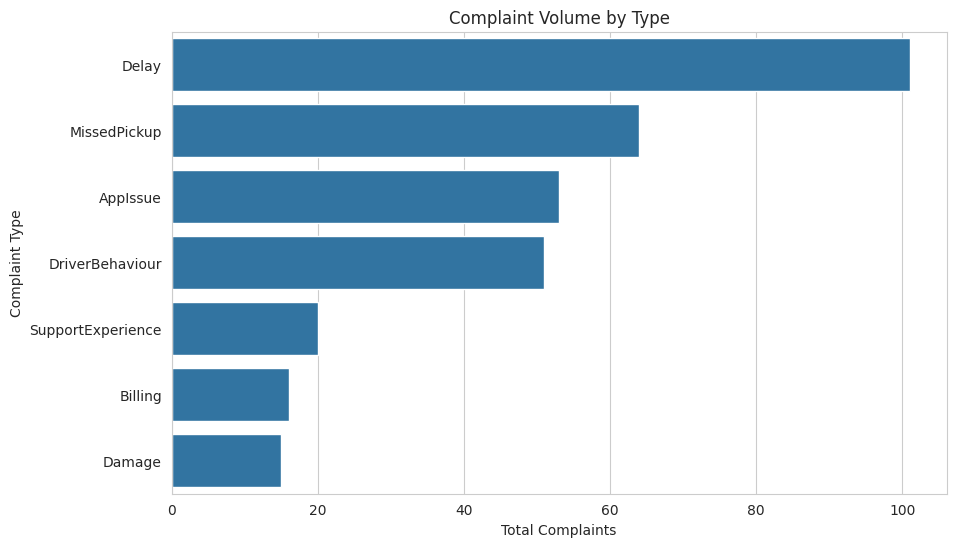

In [15]:
# CHART — COMPLAINT TYPES

plt.figure(figsize=(10,6))

sns.barplot(
    data=complaint_summary,
    x='total_complaints',
    y='complaint_type'
)

plt.title('Complaint Volume by Type')

plt.xlabel('Total Complaints')

plt.ylabel('Complaint Type')

plt.show()

In [16]:
# ANALYSIS 4 — VEHICLE PERFORMANCE

vehicle_analysis = deliveries.merge(
    vehicles,
    on='vehicle_id',
    how='left'
)

battery_stats = vehicle_analysis.groupby(
    'maintenance_status'
).agg(
    avg_battery_health=('battery_health_pct', 'mean'),
    avg_cost=('fuel_or_charge_cost', 'mean'),
    avg_distance=('route_distance_km', 'mean')
).reset_index()

battery_stats

,maintenance_status,avg_battery_health,avg_cost,avg_distance
0,Active,76.561896,12.872103,14.243247
1,InRepair,76.725984,12.904567,13.458661
2,Scheduled,78.735714,12.628506,13.477338


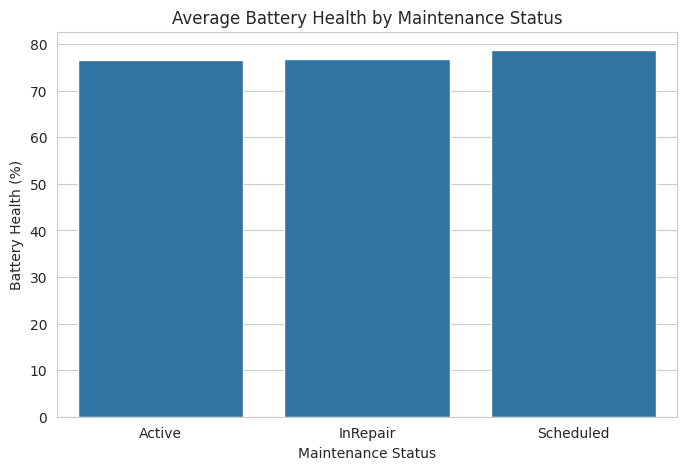

In [17]:
# CHART — BATTERY HEALTH

plt.figure(figsize=(8,5))

sns.barplot(
    data=battery_stats,
    x='maintenance_status',
    y='avg_battery_health'
)

plt.title('Average Battery Health by Maintenance Status')

plt.xlabel('Maintenance Status')

plt.ylabel('Battery Health (%)')

plt.show()

In [18]:
# ANALYSIS 5 — APP PERFORMANCE

app_analysis = app_events.groupby('zone_context').agg(
    total_events=('event_id', 'count'),
    avg_latency=('api_latency_ms', 'mean'),
    success_rate=('success_flag', 'mean')
).reset_index()

app_analysis['failure_rate'] = (
    1 - app_analysis['success_rate']
) * 100

app_analysis

,zone_context,total_events,avg_latency,success_rate,failure_rate
0,Airport,87,606.080460,0.954023,4.597701
1,Central,50,518.580000,0.920000,8.000000
2,Ctr,43,489.348837,0.930233,6.976744
3,East,91,434.714286,0.967033,3.296703
4,North,93,444.279570,0.924731,7.526882
5,Riverside,87,420.942529,0.908046,9.195402
6,South,95,428.473684,0.957895,4.210526
7,West,94,426.840426,0.946809,5.319149


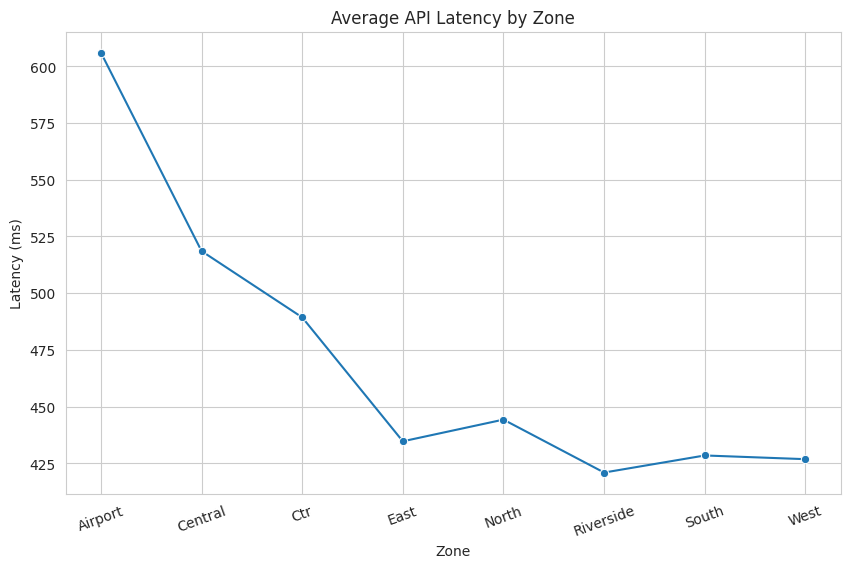

In [19]:
# CHART — API LATENCY

plt.figure(figsize=(10,6))

sns.lineplot(
    data=app_analysis,
    x='zone_context',
    y='avg_latency',
    marker='o'
)

plt.title('Average API Latency by Zone')

plt.xlabel('Zone')

plt.ylabel('Latency (ms)')

plt.xticks(rotation=20)

plt.show()

In [20]:
# CORRELATION ANALYSIS

corr_data = deliveries[[
    'route_distance_km',
    'manual_route_override_count',
    'customer_rating_post_delivery',
    'fuel_or_charge_cost'
]].dropna()

correlation_matrix = corr_data.corr()

correlation_matrix

,route_distance_km,manual_route_override_count,customer_rating_post_delivery,fuel_or_charge_cost
route_distance_km,1.000000,0.199385,0.028525,0.526552
manual_route_override_count,0.199385,1.000000,-0.059903,0.098824
customer_rating_post_delivery,0.028525,-0.059903,1.000000,-0.059062
fuel_or_charge_cost,0.526552,0.098824,-0.059062,1.000000


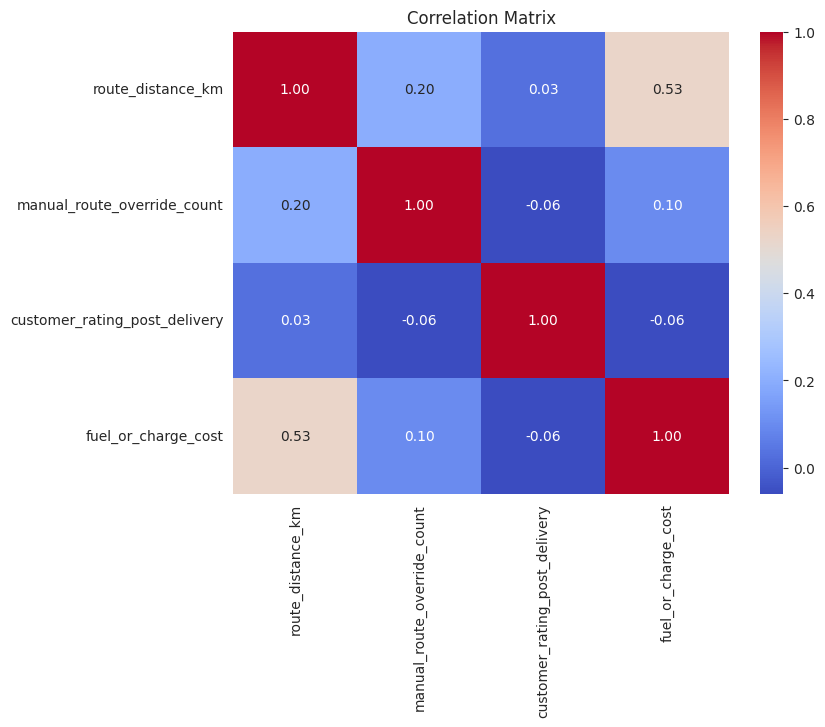

In [21]:
# CORRELATION HEATMAP

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

In [22]:
# SUMMARY STATISTICS

deliveries.describe()

,dispatch_time,delivery_completed_at,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,delivery_hours,cost_per_km
count,950,931,950.000000,950.000000,950.000000,936.000000,950.000000,931.000000,950.000000
mean,2024-12-20 13:10:27.536841984,2024-12-19 20:19:52.772387584,13.909316,0.969474,0.072632,3.864679,12.841295,9.545486,1.261662
min,2024-01-01 03:20:00,2024-01-01 15:35:48.325916,1.200000,0.000000,0.000000,1.000000,2.500000,-2.214477,0.173974
25%,2024-06-21 17:54:00,2024-06-18 14:13:03.296665088,9.135000,0.000000,0.000000,3.360000,9.925000,2.945854,0.702991
50%,2024-12-12 14:19:30,2024-12-13 02:04:50.318852096,12.840000,1.000000,0.000000,4.040000,12.645000,7.074356,0.950332
75%,2025-06-12 01:39:15,2025-06-12 00:14:26.336295936,16.835000,2.000000,0.000000,4.550000,15.697500,14.643664,1.329252
max,2025-12-31 17:27:00,2025-12-31 18:05:52.415764,41.940000,7.000000,1.000000,5.000000,29.430000,43.456918,12.363636
std,NaN,NaN,7.477907,1.093189,0.259667,0.894420,4.336468,8.648622,1.239145
